# CardioFusion: validação e interpretação

A Entrega 2 encontrou evidência computacional para oito das treze medidas candidatas, na amostra de 1.000 internações. Este notebook responde à pergunta desta etapa: **quão forte é essa evidência, e o que ela significa?**

## O que este notebook faz

| Seção | O que faz |
|---|---|
| 1 | **A evidência a testar**: o que a Entrega 2 concluiu, em números |
| 2 | **A estratégia de validação**: uma amostra nova, e as verificações de vazamento |
| 3 | **Validação**: os candidatos, o modelo, a calibração e a utilidade |
| 4 | **Interpretação**: o que os números significam, e o confronto com a literatura |
| 5 | **Limitações** |
| 6 | **Potencial biomarcador prognóstico**: o veredicto |

## A ideia central desta etapa

Um resultado obtido e medido na mesma amostra é sempre otimista demais. A Entrega 2 declarou isso e prometeu o teste: **há 22.629 internações elegíveis no MIMIC-IV, e só 1.000 foram usadas.** As outras nunca foram olhadas. É contra elas que a evidência é medida aqui.

> **Sobre as saídas.** Como nas etapas anteriores, nenhuma célula mostra linhas individuais de pacientes. Só aparecem médias, medianas, contagens e gráficos.

In [1]:
# Ferramentas: tabelas, contas, gráficos, testes e os modelos da Entrega 2.
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10})

SEED = 42
OUTCOME = "obito_hospitalar"
rng = np.random.default_rng(SEED)

DESENVOLVIMENTO = Path("../data/cohort")  # as 1.000 internações da Entrega 2
COMPLETA = Path("../data/cohort_full")  # as 22.629 elegíveis
VALIDACAO = Path("../data/cohort_validation")  # a amostra nova, extraída para esta etapa

print("dados encontrados:", all(p.exists() for p in [DESENVOLVIMENTO, COMPLETA, VALIDACAO]))

dados encontrados: True


## 1 A evidência a testar

A Entrega 2 usou um critério de duas perguntas, fixado antes dos resultados: o candidato precisava **separar os grupos** (Mann-Whitney com correção de Benjamini-Hochberg, p corrigido < 0,05) e **melhorar a previsão** em pelo menos 0,010 de AUC sobre um modelo de referência de idade e Glasgow.

O quadro abaixo é o resultado daquela etapa, transcrito para servir de ponto de partida. Nada aqui é recalculado: são os números que a validação vai confrontar.

In [2]:
# Resultado da Entrega 2 (notebook 02, seção 5.2). Transcrito, não recalculado.
ENTREGA_2 = pd.DataFrame(
    [
        ("RDW", 0.080, True),
        ("Anion Gap", 0.072, True),
        ("Lactate", 0.054, True),
        ("Bicarbonate", 0.037, True),
        ("Urea Nitrogen", 0.037, True),
        ("Systolic BP", 0.027, True),
        ("Creatinine", 0.016, True),
        ("Heart Rate", 0.013, True),
        ("razao_ureia_creatinina", 0.002, False),
        ("razao_neutrofilos_linfocitos", 0.001, False),
        ("Sodium", 0.000, False),
        ("Respiratory Rate", -0.003, False),
        ("Hemoglobin", -0.005, False),
    ],
    columns=["medida", "ganho_entrega2", "sustentado_entrega2"],
)
AUC_REFERENCIA_E2, AUC_FINAL_E2 = 0.672, 0.765

print(f"sustentados na Entrega 2: {ENTREGA_2.sustentado_entrega2.sum()} de {len(ENTREGA_2)}")
print(f"modelo de referência (idade + Glasgow): AUC {AUC_REFERENCIA_E2}")
print(f"modelo final (referência + RDW + ânion gap): AUC {AUC_FINAL_E2}")
ENTREGA_2

sustentados na Entrega 2: 8 de 13
modelo de referência (idade + Glasgow): AUC 0.672
modelo final (referência + RDW + ânion gap): AUC 0.765


,medida,ganho_entrega2,sustentado_entrega2
0,RDW,0.080,True
1,Anion Gap,0.072,True
2,Lactate,0.054,True
3,Bicarbonate,0.037,True
4,Urea Nitrogen,0.037,True
5,Systolic BP,0.027,True
6,Creatinine,0.016,True
7,Heart Rate,0.013,True
8,razao_ureia_creatinina,0.002,False
9,razao_neutrofilos_linfocitos,0.001,False


## 2 A estratégia de validação

### 2.1 De onde vem a amostra nova

A extração original do MIMIC-IV reuniu **22.629 internações** com insuficiência cardíaca e passagem por UTI. A Entrega 2 sorteou 1.000 delas. As restantes são material nunca observado, e é a melhor validação disponível sem sair deste hospital.

Uma internação a mais não basta para ser amostra independente. **O mesmo paciente pode ter várias internações**, e um paciente que aparece nas duas amostras carregaria para a validação tudo o que o modelo aprendeu dele: idade, fisiologia, padrão de exames. Por isso a validação exclui não só as 1.000 internações de desenvolvimento, mas **toda internação de qualquer paciente que apareça nelas**.

In [3]:
# A coorte completa e a amostra de desenvolvimento definem, por exclusão, a de validação.
completa = pd.read_parquet(COMPLETA / "cohort.parquet")
desenvolvimento = pd.read_parquet(DESENVOLVIMENTO / "cohort.parquet")

internacoes_dev = set(desenvolvimento.hadm_id)
pacientes_dev = set(desenvolvimento.subject_id)

mesma_internacao = completa.hadm_id.isin(internacoes_dev)
mesmo_paciente = completa.subject_id.isin(pacientes_dev) & ~mesma_internacao
validacao = completa[~mesma_internacao & ~completa.subject_id.isin(pacientes_dev)].copy()

print(f"elegíveis no MIMIC-IV:                        {len(completa):>7,}")
print(f"  usadas na Entrega 2 (desenvolvimento):      {int(mesma_internacao.sum()):>7,}")
print(f"  excluídas por serem do mesmo paciente:      {int(mesmo_paciente.sum()):>7,}")
print(f"  restam para validação:                      {len(validacao):>7,}")
print()
print(f"mortalidade no desenvolvimento: {desenvolvimento[OUTCOME].mean():.1%}")
print(f"mortalidade na validação:       {validacao[OUTCOME].mean():.1%}")
print(
    f"idade mediana: desenvolvimento {desenvolvimento.idade.median():.0f} anos, "
    f"validação {validacao.idade.median():.0f} anos"
)

elegíveis no MIMIC-IV:                         22,629
  usadas na Entrega 2 (desenvolvimento):        1,000
  excluídas por serem do mesmo paciente:        1,010
  restam para validação:                       20,619

mortalidade no desenvolvimento: 16.5%
mortalidade na validação:       15.2%
idade mediana: desenvolvimento 74 anos, validação 74 anos


> **O que isso mostra.** Sobram **20.619 internações** que nenhuma etapa deste projeto olhou, vinte vezes o material da Entrega 2.
>
> As 1.010 excluídas por pertencerem a pacientes já vistos são 5% da coorte, e são justamente as que mais inflariam o resultado: um paciente reinternado traz a mesma idade, a mesma fisiologia e o mesmo padrão de exames que o modelo já aprendeu dele.
>
> As duas amostras são parecidas o bastante para que a comparação seja sobre o modelo, e não sobre populações diferentes: a idade mediana é 74 anos nas duas e a mortalidade vai de 16,5% para 15,2%. Essa diferença de 1,3 ponto é do sorteio, e ela mesma já mostra a variação que uma amostra de mil casos carrega.

### 2.2 Vazamento: as cinco portas que precisam estar fechadas

Vazamento é quando a resposta entra no modelo por uma porta lateral. Cada porta abaixo foi fechada de propósito, e a célula seguinte confere.

**A resposta em outra coluna.** O corte tem `desfecho` (local de alta, que inclui a categoria óbito), `alta_em` e o tempo de permanência. Nenhuma entra nos modelos: a primeira contém a resposta e as outras duas só existem quando a internação termina.

**Medida fora da janela.** Tudo o que o modelo usa precisa ter sido registrado entre a entrada na UTI e 24 horas depois.

**O mesmo paciente nas duas amostras.** Tratado na seção 2.1.

**Limites aprendidos na validação.** Os cortes da winsorização e os coeficientes vêm só do desenvolvimento. Se os percentis fossem calculados na amostra de validação, ela teria informado o próprio tratamento.

**Escolha de variável feita depois de olhar a validação.** As medidas testadas aqui são as treze da Entrega 2, e o modelo é o que a Entrega 2 declarou. Nada foi escolhido depois.

In [4]:
# Confere as portas que dependem dos dados.
gcs_val = pd.read_parquet(VALIDACAO / "gcs_timeseries.parquet")
vitais_val = pd.read_parquet(VALIDACAO / "vitals_timeseries.parquet")
labs_ts = pd.read_parquet(COMPLETA / "labs_timeseries.parquet")
labs_val_ts = labs_ts[labs_ts.hadm_id.isin(set(validacao.hadm_id))]

print("pacientes em comum entre as amostras:", len(pacientes_dev & set(validacao.subject_id)))
print("internações em comum:", len(internacoes_dev & set(validacao.hadm_id)))
print()
for nome, tabela in [("exames", labs_val_ts), ("sinais vitais", vitais_val), ("Glasgow", gcs_val)]:
    h = tabela.horas_da_janela
    print(
        f"{nome:14} {len(tabela):>9,} medições | janela de {h.min():.2f} a {h.max():.2f} horas "
        f"| fora de 0–24h: {int(((h < 0) | (h > 24)).sum())}"
    )
print()
PROIBIDAS = ["desfecho", "alta_em", "admissao_em", "raca", "tempo_permanencia"]
print(
    "colunas que existem no corte e nunca entram nos modelos:",
    ", ".join(c for c in PROIBIDAS if c in completa.columns),
)

pacientes em comum entre as amostras: 0
internações em comum: 0

exames         1,518,865 medições | janela de 0.00 a 24.00 horas | fora de 0–24h: 0
sinais vitais  3,390,799 medições | janela de 0.00 a 24.00 horas | fora de 0–24h: 0
Glasgow          119,578 medições | janela de 0.00 a 24.00 horas | fora de 0–24h: 0

colunas que existem no corte e nunca entram nos modelos: desfecho, alta_em, admissao_em, raca


> **O que isso mostra.** As quatro portas verificáveis estão fechadas: nenhum paciente e nenhuma internação em comum, e todas as medições, nos três tipos de dado, caem entre 0 e 24 horas, sem uma única exceção.
>
> A quinta porta não é verificável por código, e sim por procedência: as medidas testadas aqui são as treze que a Entrega 2 declarou, e o modelo é o que ela recomendou. Nada foi escolhido depois de ver a validação.

### 2.3 As variáveis, montadas do mesmo jeito nas duas amostras

Qualquer diferença de construção entre desenvolvimento e validação viraria diferença de resultado, e seria confundida com perda de desempenho. Por isso a mesma função monta as duas matrizes: **valor de chegada** de cada exame e sinal vital, Glasgow da admissão, e as contas derivadas da Entrega 1.

Os limites da winsorização são calculados **uma vez, no desenvolvimento**, e aplicados aos dois lados.

In [5]:
labs_largo = pd.read_parquet(COMPLETA / "labs_wide.parquet")  # um valor por exame e internação

EXAMES = [
    "RDW",
    "Anion Gap",
    "Urea Nitrogen",
    "Creatinine",
    "Bicarbonate",
    "Lactate",
    "Sodium",
    "Hemoglobin",
    "Albumin",
    "Neutrophils",
    "Lymphocytes",
]
VITAIS = ["Systolic BP", "Heart Rate", "Respiratory Rate"]
REFERENCIA = ["idade", "gcs_admissao"]


def primeiro_valor(tabela, coluna_nome):
    """Primeira medida de cada tipo dentro da janela de 24 horas."""
    return (
        tabela.sort_values("horas_da_janela")
        .groupby(["hadm_id", coluna_nome])
        .valor.first()
        .unstack()
    )


def montar(coorte, vitais, gcs):
    """Matriz de análise: uma linha por internação, as mesmas colunas nas duas amostras."""
    X = coorte.set_index("hadm_id")[["idade", OUTCOME]].copy()
    X[OUTCOME] = X[OUTCOME].astype(int)
    X = X.join(labs_largo[EXAMES])
    X = X.join(primeiro_valor(vitais, "sinal").reindex(columns=VITAIS))

    por_internacao = gcs.sort_values("horas_da_janela").groupby("hadm_id")
    X["gcs_admissao"] = por_internacao["GCS total"].first()
    X["gcs_minimo"] = por_internacao["GCS total"].min()
    # reindexar introduz ausentes em quem não tem Glasgow; a coluna precisa ser booleana
    X["glasgow_intubado"] = (
        por_internacao.verbal_intubado.any().reindex(X.index).fillna(False).astype(bool)
    )

    pressao = vitais[vitais.sinal == "Systolic BP"].sort_values("horas_da_janela")
    X["origem_pressao"] = pressao.groupby("hadm_id").origem.first()

    X["razao_ureia_creatinina"] = X["Urea Nitrogen"] / X["Creatinine"]
    # zero linfócitos tornaria a divisão impossível; fica ausente
    X["razao_neutrofilos_linfocitos"] = X["Neutrophils"] / X["Lymphocytes"].where(
        X["Lymphocytes"] > 0
    )
    X["pediram_lactato"] = X["Lactate"].notna().astype(int)
    X["pediram_albumina"] = X["Albumin"].notna().astype(int)
    return X


dev = montar(
    desenvolvimento,
    pd.read_parquet(DESENVOLVIMENTO / "vitals_timeseries.parquet"),
    pd.read_parquet(DESENVOLVIMENTO / "gcs_timeseries.parquet"),
)
val = montar(validacao, vitais_val, gcs_val)

# winsorização nos percentis 1 e 99, com os limites vindos só do desenvolvimento
PARA_LIMITAR = EXAMES + VITAIS
LIMITES = {c: (dev[c].quantile(0.01), dev[c].quantile(0.99)) for c in PARA_LIMITAR}
for coluna, (baixo, alto) in LIMITES.items():
    dev[coluna] = dev[coluna].clip(baixo, alto)
    val[coluna] = val[coluna].clip(baixo, alto)
for tabela in (dev, val):  # as contas derivadas usam os valores já limitados
    tabela["razao_ureia_creatinina"] = tabela["Urea Nitrogen"] / tabela["Creatinine"]
    tabela["razao_neutrofilos_linfocitos"] = tabela["Neutrophils"] / tabela["Lymphocytes"].where(
        tabela["Lymphocytes"] > 0
    )

print(f"desenvolvimento: {dev.shape[0]:,} internações × {dev.shape[1]} colunas")
print(f"validação:       {val.shape[0]:,} internações × {val.shape[1]} colunas")
print("\npreenchimento na validação, nas medidas do modelo final:")
for c in ["idade", "gcs_admissao", "RDW", "Anion Gap"]:
    print(f"  {c:14} {val[c].notna().mean():6.1%}")

desenvolvimento: 1,000 internações × 24 colunas
validação:       20,619 internações × 24 colunas

preenchimento na validação, nas medidas do modelo final:
  idade          100.0%
  gcs_admissao    99.5%
  RDW             97.4%
  Anion Gap       98.1%


> **O que isso mostra.** O modelo final é aplicável a quase toda a coorte nova: Glasgow em 99,5% das internações, ânion gap em 98,1% e RDW em 97,4%. Isso não é detalhe operacional, é parte do argumento. Um modelo que só funciona em quem tem um exame raro não serve para triagem, e foi por isso que a Entrega 2 preferiu esses dois exames aos demais.

## 3 Validação

### 3.1 Os candidatos se repetem na amostra nova?

O procedimento é o da Entrega 2, com uma diferença que é o ponto desta etapa: **o modelo é ajustado no desenvolvimento e medido na validação**. O ganho é a diferença de AUC entre o modelo de referência (idade e Glasgow) e o mesmo modelo com o candidato, ambos medidos nas internações novas.

In [6]:
def auc_validado(colunas):
    """Ajusta no desenvolvimento, mede na validação. Devolve a AUC e o n de cada lado."""
    treino = dev[colunas + [OUTCOME]].dropna()
    teste = val[colunas + [OUTCOME]].dropna()
    modelo = LogisticRegression(max_iter=2000).fit(treino[colunas], treino[OUTCOME])
    risco = modelo.predict_proba(teste[colunas])[:, 1]
    return {
        "auc": roc_auc_score(teste[OUTCOME], risco),
        "n_treino": len(treino),
        "n_validacao": len(teste),
        "risco": risco,
        "y": teste[OUTCOME].to_numpy(),
    }


CANDIDATOS = [
    "Urea Nitrogen",
    "razao_ureia_creatinina",
    "Creatinine",
    "RDW",
    "Anion Gap",
    "Bicarbonate",
    "Lactate",
    "razao_neutrofilos_linfocitos",
    "Hemoglobin",
    "Sodium",
    "Systolic BP",
    "Heart Rate",
    "Respiratory Rate",
]

linhas = []
for medida in CANDIDATOS:
    # a referência é medida na MESMA população do candidato, como na Entrega 2
    colunas = REFERENCIA + [medida]
    treino = dev[colunas + [OUTCOME]].dropna()
    teste = val[colunas + [OUTCOME]].dropna()
    sem = LogisticRegression(max_iter=2000).fit(treino[REFERENCIA], treino[OUTCOME])
    com = LogisticRegression(max_iter=2000).fit(treino[colunas], treino[OUTCOME])
    auc_sem = roc_auc_score(teste[OUTCOME], sem.predict_proba(teste[REFERENCIA])[:, 1])
    auc_com = roc_auc_score(teste[OUTCOME], com.predict_proba(teste[colunas])[:, 1])
    s = teste[[medida, OUTCOME]]
    p = stats.mannwhitneyu(s[s[OUTCOME] == 0][medida], s[s[OUTCOME] == 1][medida]).pvalue
    linhas.append(
        {
            "medida": medida,
            "n_validacao": len(teste),
            "AUC sem": round(auc_sem, 3),
            "AUC com": round(auc_com, 3),
            "ganho na validação": round(auc_com - auc_sem, 3),
            "p (Mann-Whitney)": p,
        }
    )

replicacao = (
    pd.DataFrame(linhas)
    .merge(ENTREGA_2.rename(columns={"medida": "medida"}), on="medida", how="left")
    .sort_values("ganho_entrega2", ascending=False)
)
replicacao["separa"] = replicacao["p (Mann-Whitney)"] < 0.05
replicacao["ganha ao menos 0,010"] = replicacao["ganho na validação"] >= 0.010
replicacao["sustentado na validação"] = replicacao.separa & replicacao["ganha ao menos 0,010"]
replicacao["p (Mann-Whitney)"] = replicacao["p (Mann-Whitney)"].map("{:.1e}".format)

print(f"sustentados na Entrega 2: {int(replicacao.sustentado_entrega2.sum())}")
print(f"sustentados na validação: {int(replicacao['sustentado na validação'].sum())}")
print(
    f"mudaram de lado: {int((replicacao.sustentado_entrega2 != replicacao['sustentado na validação']).sum())}"
)
replicacao[
    [
        "medida",
        "n_validacao",
        "ganho_entrega2",
        "ganho na validação",
        "p (Mann-Whitney)",
        "sustentado_entrega2",
        "sustentado na validação",
    ]
]

sustentados na Entrega 2: 8
sustentados na validação: 10
mudaram de lado: 2


,medida,n_validacao,ganho_entrega2,ganho na validação,p (Mann-Whitney),sustentado_entrega2,sustentado na validação
3,RDW,20008,0.080,0.057,6.2e-96,True,True
4,Anion Gap,20151,0.072,0.068,1.5e-135,True,True
6,Lactate,12828,0.054,0.077,3.9e-106,True,True
5,Bicarbonate,20165,0.037,0.030,2.6e-79,True,True
0,Urea Nitrogen,20166,0.037,0.045,3.1e-122,True,True
10,Systolic BP,20406,0.027,0.022,1.7e-48,True,True
2,Creatinine,20175,0.016,0.027,2.0e-87,True,True
11,Heart Rate,20516,0.013,0.021,3.4e-29,True,True
1,razao_ureia_creatinina,20165,0.002,0.004,9.1e-14,False,False
7,razao_neutrofilos_linfocitos,7789,0.001,0.030,4.6e-40,False,True


> **O que isso mostra, e é o resultado central desta etapa.** **Os oito candidatos sustentados na Entrega 2 continuam sustentados nas internações novas.** Nenhum caiu.
>
> Os ganhos se movem, como se espera de qualquer medida refeita em outra amostra, e em direções diferentes. RDW cai de 0,080 para 0,057 e bicarbonato de 0,037 para 0,030; ureia sobe de 0,037 para 0,045, creatinina de 0,016 para 0,027 e o lactato de 0,054 para 0,077. Ânion gap fica praticamente igual, 0,072 contra 0,068. O que não se move é a conclusão.
>
> **Dois candidatos mudaram de lado, e os dois para melhor.** A frequência respiratória, que na Entrega 2 tinha ganho negativo, rende 0,031 aqui; a razão neutrófilos/linfócitos, que tinha 0,001, rende 0,030. Ambos com valor-p minúsculo. A leitura honesta é que a amostra de mil não só infla o que é grande: ela também apaga o que é pequeno, e esses dois foram apagados.
>
> Duas ressalvas de tamanho de população acompanham esses números. O lactato é medido em 12.828 das 20.619 internações, e a razão neutrófilos/linfócitos em apenas 7.789. Os ganhos deles valem para quem teve o exame pedido, que é um grupo já escolhido pelo médico. A seção 4.2 volta a isso.
>
> **Três candidatos seguem sem sustentação**: razão ureia/creatinina, sódio e hemoglobina. A seção 4.1 mostra que isso não é falta de sinal.

### 3.2 O modelo, medido fora da amostra

Dois modelos interessam: o **de referência**, com idade e Glasgow, que é o que se sabe antes de qualquer exame; e o **final**, que a Entrega 2 recomendou, com RDW e ânion gap acrescentados.

Duas AUC são reportadas para cada um. A do desenvolvimento vem de validação cruzada dentro das 1.000 internações, e é a que a Entrega 2 publicou. A da validação vem de treinar nas 1.000 e medir nas internações novas. A diferença entre as duas é o **otimismo** que a Entrega 2 não podia medir.

O intervalo de confiança vem de reamostragem: sorteamos, mil vezes, um conjunto do mesmo tamanho da validação com reposição, e recalculamos a AUC. O intervalo guarda os 95% centrais.

In [7]:
def auc_cruzada(colunas):
    """AUC por validação cruzada dentro do desenvolvimento, como na Entrega 2."""
    dados = dev[colunas + [OUTCOME]].dropna()
    particoes = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    notas = cross_val_score(
        LogisticRegression(max_iter=2000),
        dados[colunas],
        dados[OUTCOME],
        cv=particoes,
        scoring="roc_auc",
    )
    return notas.mean(), len(dados)


def intervalo_auc(y, risco, repeticoes=1000):
    """Intervalo de 95% por reamostragem com reposição."""
    aucs = [roc_auc_score(y[i], risco[i]) for i in rng.integers(0, len(y), (repeticoes, len(y)))]
    return np.percentile(aucs, [2.5, 97.5])


MODELO_REFERENCIA = REFERENCIA
MODELO_FINAL = REFERENCIA + ["RDW", "Anion Gap"]

resultados = {}
for nome, colunas in [
    ("referência: idade + Glasgow", MODELO_REFERENCIA),
    ("final: + RDW + ânion gap", MODELO_FINAL),
]:
    cruzada, n_dev = auc_cruzada(colunas)
    r = auc_validado(colunas)
    baixo, alto = intervalo_auc(r["y"], r["risco"])
    resultados[nome] = {**r, "cruzada": cruzada, "n_dev": n_dev, "ic": (baixo, alto)}
    print(f"{nome}")
    print(f"  desenvolvimento (validação cruzada, n={n_dev:,}): AUC {cruzada:.3f}")
    print(
        f"  validação (n={r['n_validacao']:,}):                AUC {r['auc']:.3f} "
        f"[{baixo:.3f}–{alto:.3f}]"
    )
    print(f"  otimismo: {cruzada - r['auc']:+.3f}")
    print()

final = resultados["final: + RDW + ânion gap"]
ref = resultados["referência: idade + Glasgow"]
print(
    f"ganho do modelo final sobre a referência, na validação: " f"{final['auc'] - ref['auc']:+.3f}"
)

referência: idade + Glasgow
  desenvolvimento (validação cruzada, n=996): AUC 0.672
  validação (n=20,516):                AUC 0.624 [0.613–0.634]
  otimismo: +0.048



final: + RDW + ânion gap
  desenvolvimento (validação cruzada, n=965): AUC 0.765
  validação (n=19,960):                AUC 0.713 [0.703–0.723]
  otimismo: +0.052

ganho do modelo final sobre a referência, na validação: +0.089


> **O que isso mostra.** O desempenho absoluto cai, e cai nos dois modelos: a referência vai de 0,672 para 0,624, e o modelo final de 0,765 para 0,713. O otimismo é de cerca de cinco pontos em ambos, e era previsível: validação cruzada dentro de mil casos reaproveita a mesma amostra para ajustar e medir.
>
> Mas olhe o que **não** caiu. O ganho do modelo final sobre a referência era de 0,093 no desenvolvimento e é de **0,089 na validação**. O que era otimista era o patamar, não o acréscimo. É uma distinção que importa para a pergunta do projeto: a evidência é sobre os biomarcadores acrescentarem informação, e é exatamente essa parte que se sustentou.
>
> O intervalo de 0,703 a 0,723 vem de reamostragem, e é estreito porque a amostra é grande. Ele não cobre 0,765: o valor publicado na Entrega 2 está fora do que a validação admite, e essa é a medida do otimismo que faltava.

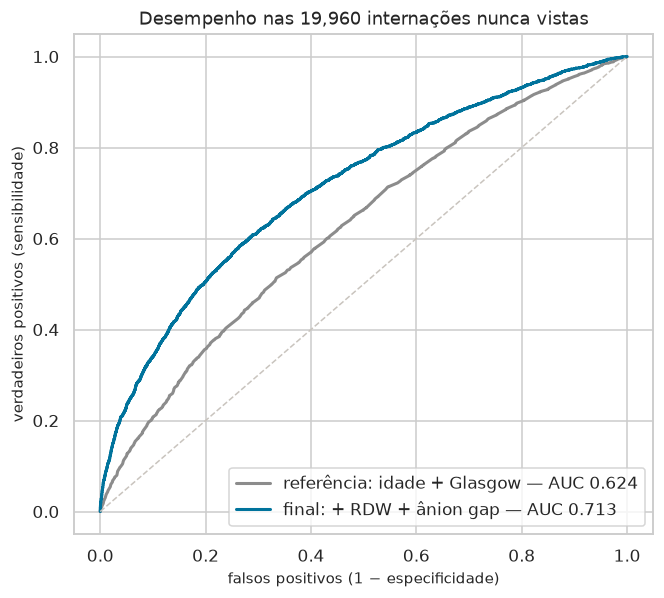

In [8]:
# As curvas ROC dos dois modelos na amostra de validação.
fig, eixo = plt.subplots(figsize=(6.2, 5.6))
for nome, cor in [
    ("referência: idade + Glasgow", "#8c8c8c"),
    ("final: + RDW + ânion gap", "#00739c"),
]:
    r = resultados[nome]
    fpr, tpr, _ = roc_curve(r["y"], r["risco"])
    eixo.plot(fpr, tpr, color=cor, linewidth=2, label=f"{nome} — AUC {r['auc']:.3f}")
eixo.plot([0, 1], [0, 1], "--", color="#c9c4be", linewidth=1)
eixo.set_xlabel("falsos positivos (1 − especificidade)")
eixo.set_ylabel("verdadeiros positivos (sensibilidade)")
eixo.set_title(f"Desempenho nas {final['n_validacao']:,} internações nunca vistas")
eixo.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

> **Como ler este gráfico.** A curva do modelo final fica acima da de referência em toda a extensão, e a distância é maior no canto esquerdo, onde a decisão clínica opera: identificar um grupo pequeno de risco alto sem alarmar a unidade inteira.

### 3.3 Calibração: o risco previsto corresponde ao observado?

A AUC só mede ordenação: se ela fosse a única medida, um modelo que dissesse "5%" para todo mundo, na ordem certa, pareceria ótimo. Para apoiar decisão, o número precisa valer como probabilidade.

Três formas de olhar isso. O **risco médio previsto** contra a mortalidade observada mostra se o modelo acerta o patamar geral. A **inclinação de calibração** mostra se ele exagera: acima de 1 significa previsões tímidas demais, abaixo de 1 significa extremos exagerados. E a comparação **por décimo de risco** mostra onde o erro está.

In [9]:
risco, y = final["risco"], final["y"]

previsto_medio, observado = risco.mean(), y.mean()
logito = np.log(risco / (1 - risco))
recalibragem = LogisticRegression(max_iter=2000).fit(logito.reshape(-1, 1), y)
inclinacao, intercepto = recalibragem.coef_[0][0], recalibragem.intercept_[0]

print(f"risco médio previsto:      {previsto_medio:.1%}")
print(f"mortalidade observada:     {observado:.1%}")
print(f"inclinação de calibração:  {inclinacao:.3f}   (1,0 seria perfeito)")
print(f"intercepto:                {intercepto:+.3f}   (0 seria perfeito)")
print()
print(f"Brier do modelo:                        {brier_score_loss(y, risco):.4f}")
print(
    f"Brier de quem só repete a prevalência:  {brier_score_loss(y, np.full_like(risco, observado)):.4f}"
)

decis = pd.DataFrame({"risco": risco, "obito": y})
decis["decimo"] = pd.qcut(decis.risco, 10, labels=False) + 1
tabela_decis = decis.groupby("decimo").agg(
    previsto=("risco", "mean"), observado=("obito", "mean"), n=("obito", "size")
)
tabela_decis["diferença"] = tabela_decis.observado - tabela_decis.previsto
print("\ndécimo | previsto | observado | diferença |      n")
for decimo, linha in tabela_decis.iterrows():
    print(
        f"  {decimo:>2}   | {linha.previsto:7.1%}  | {linha.observado:8.1%}  | {linha['diferença']:+8.1%}  | {int(linha.n):,}"
    )

risco médio previsto:      15.8%
mortalidade observada:     14.6%
inclinação de calibração:  0.747   (1,0 seria perfeito)
intercepto:                -0.470   (0 seria perfeito)

Brier do modelo:                        0.1142
Brier de quem só repete a prevalência:  0.1250

décimo | previsto | observado | diferença |      n
   1   |    2.3%  |     4.4%  |    +2.2%  | 1,996
   2   |    4.2%  |     6.8%  |    +2.6%  | 1,996
   3   |    5.9%  |     7.3%  |    +1.4%  | 1,996
   4   |    7.7%  |     9.1%  |    +1.3%  | 1,996
   5   |    9.9%  |    10.0%  |    +0.1%  | 1,996
   6   |   12.4%  |    11.2%  |    -1.2%  | 1,996
   7   |   15.9%  |    14.2%  |    -1.6%  | 1,996
   8   |   20.7%  |    18.2%  |    -2.5%  | 1,996
   9   |   28.8%  |    24.2%  |    -4.6%  | 1,996
  10   |   50.6%  |    41.1%  |    -9.5%  | 1,996


> **O que isso mostra.** O patamar geral está certo: 15,8% de risco médio previsto contra 14,6% de mortalidade observada. O problema está na inclinação, 0,747 em vez de 1,0, e a tabela de décimos mostra onde: o modelo **subestima embaixo e exagera no topo**. No primeiro décimo prevê 2,3% e acontece 4,4%; no último prevê 50,6% e acontece 41,1%.
>
> É o comportamento típico de um modelo ajustado em amostra pequena: os coeficientes saem grandes demais e as previsões ficam esticadas para as pontas. A ordenação, que é o que a AUC mede, continua boa; as probabilidades, não.
>
> A consequência prática é direta e precisa constar em qualquer uso: **o modelo serve para ordenar pacientes por risco, não para anunciar a probabilidade de um paciente**. Para anunciar probabilidade ele precisa ser recalibrado, e a recalibração é uma conta simples, feita com estes mesmos dados.
>
> O Brier cai de 0,1250, de quem só repete a prevalência, para 0,1142. São 8,6% de redução: um avanço modesto, e é bom ver isso ao lado da AUC de 0,713, que soa melhor do que é.

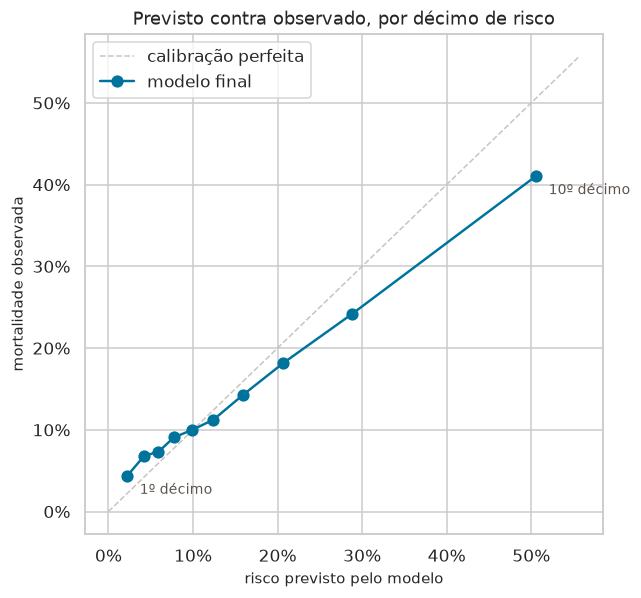

In [10]:
# Calibração por décimo de risco: cada ponto é um décimo da amostra de validação.
fig, eixo = plt.subplots(figsize=(6.0, 5.6))
eixo.plot(
    [0, tabela_decis.previsto.max() * 1.1],
    [0, tabela_decis.previsto.max() * 1.1],
    "--",
    color="#c9c4be",
    linewidth=1,
    label="calibração perfeita",
)
eixo.plot(
    tabela_decis.previsto,
    tabela_decis.observado,
    "o-",
    color="#00739c",
    markersize=7,
    linewidth=1.6,
    label="modelo final",
)
for decimo, linha in tabela_decis.iterrows():
    if decimo in (1, 10):
        eixo.annotate(
            f"{decimo}º décimo",
            (linha.previsto, linha.observado),
            textcoords="offset points",
            xytext=(8, -12),
            fontsize=9,
            color="#5c534d",
        )
eixo.set_xlabel("risco previsto pelo modelo")
eixo.set_ylabel("mortalidade observada")
eixo.set_title("Previsto contra observado, por décimo de risco")
eixo.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
eixo.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
eixo.legend(frameon=True)
plt.tight_layout()
plt.show()

> **Como ler este gráfico.** A linha tracejada é a calibração perfeita. Os pontos ficam acima dela nos décimos de risco baixo e abaixo nos de risco alto, cruzando perto do meio. É a inclinação de 0,747 desenhada: o modelo comprime a realidade nas pontas.

### 3.4 Utilidade: o modelo mudaria alguma conduta?

A decisão que o projeto quer apoiar é reconhecer quem precisa de vigilância mais estreita. Isso se traduz em escolher um grupo para observar de perto, e a pergunta prática é quanto esse grupo concentra de óbito.

Três faixas de corte, e para cada uma o que o médico precisaria saber: **quantos pacientes entram**, **que fração dos óbitos o grupo captura** (sensibilidade), e **quantos dos escolhidos realmente falecem** (valor preditivo positivo). Nenhum corte é recomendado aqui: os três mostram a troca.

In [11]:
ordenado = np.sort(risco)[::-1]
linhas = []
for fracao in (0.05, 0.10, 0.20):
    corte = ordenado[int(fracao * len(risco)) - 1]
    sinalizado = risco >= corte
    linhas.append(
        {
            "faixa sinalizada": f"{fracao:.0%} de maior risco",
            "limiar de risco": f"{corte:.1%}",
            "pacientes": int(sinalizado.sum()),
            "óbitos capturados": f"{y[sinalizado].sum() / y.sum():.1%}",
            "mortalidade no grupo": f"{y[sinalizado].mean():.1%}",
            "mortalidade fora": f"{y[~sinalizado].mean():.1%}",
        }
    )
utilidade = pd.DataFrame(linhas)
print(f"prevalência de óbito na validação: {y.mean():.1%}")
print(f"mortalidade nos 50% de menor risco: {y[risco <= np.median(risco)].mean():.1%}")
utilidade

prevalência de óbito na validação: 14.6%
mortalidade nos 50% de menor risco: 7.5%


,faixa sinalizada,limiar de risco,pacientes,óbitos capturados,mortalidade no grupo,mortalidade fora
0,5% de maior risco,46.6%,998,17.2%,50.5%,12.8%
1,10% de maior risco,35.1%,1996,28.0%,41.1%,11.7%
2,20% de maior risco,23.9%,3992,44.6%,32.6%,10.2%


> **O que isso mostra.** Aqui a evidência encontra a decisão que o projeto quer apoiar.
>
> Sinalizando os **5% de maior risco**, o grupo tem metade de mortalidade (50,5%) contra 12,8% no resto. São 998 pacientes, e eles contêm 17,2% de todos os óbitos. Sinalizando os **20%**, a mortalidade do grupo é 32,6% e ele já contém 44,6% dos óbitos.
>
> Do outro lado, a metade de menor risco tem 7,5% de mortalidade, metade da prevalência geral.
>
> É uma troca, não uma solução: nenhum corte captura a maioria dos óbitos sem sinalizar muita gente. Quem escolhe o corte é a unidade, em função do que a sinalização custa e do que ela muda.

### 3.5 A trajetória do dia sobrevive fora da amostra?

A Entrega 2 comparou o valor de chegada com cinco resumos da janela de 24 horas e reportou o vencedor de cada exame, declarando no mesmo parágrafo que escolher o melhor entre seis e mostrar só ele infla o resultado. Aqui está o teste: os três vencedores de lá, medidos na amostra nova, com o modelo ajustado no desenvolvimento.

In [12]:
serie = pd.read_parquet(COMPLETA / "labs_timeseries.parquet")


def resumo_da_janela(hadms, exame, tipo):
    """Valor de chegada e o resumo escolhido, por internação."""
    s = serie[(serie.exame == exame) & serie.hadm_id.isin(hadms)].sort_values("horas_da_janela")
    g = s.groupby("hadm_id").valor
    return pd.DataFrame({"chegada": g.first(), "resumo": g.min() if tipo == "minimo" else g.mean()})


VENCEDORES_E2 = [
    ("Lactate", "minimo", 0.033),
    ("Bicarbonate", "minimo", 0.030),
    ("Anion Gap", "media", 0.021),
]
linhas = []
for exame, tipo, diferenca_e2 in VENCEDORES_E2:
    r_dev = (
        resumo_da_janela(set(dev.index), exame, tipo)
        .join(dev[REFERENCIA + [OUTCOME]], how="inner")
        .dropna()
    )
    r_val = (
        resumo_da_janela(set(val.index), exame, tipo)
        .join(val[REFERENCIA + [OUTCOME]], how="inner")
        .dropna()
    )
    aucs = {}
    for qual in ("chegada", "resumo"):
        colunas = REFERENCIA + [qual]
        m = LogisticRegression(max_iter=2000).fit(r_dev[colunas], r_dev[OUTCOME])
        aucs[qual] = roc_auc_score(r_val[OUTCOME], m.predict_proba(r_val[colunas])[:, 1])
    linhas.append(
        {
            "exame": exame,
            "resumo vencedor na Entrega 2": tipo,
            "diferença na Entrega 2": diferenca_e2,
            "AUC do valor de chegada": round(aucs["chegada"], 3),
            "AUC do resumo": round(aucs["resumo"], 3),
            "diferença na validação": round(aucs["resumo"] - aucs["chegada"], 3),
            "n": len(r_val),
        }
    )
trajetoria = pd.DataFrame(linhas)
trajetoria

,exame,resumo vencedor na Entrega 2,diferença na Entrega 2,AUC do valor de chegada,AUC do resumo,diferença na validação,n
0,Lactate,minimo,0.033,0.674,0.684,0.010,12828
1,Bicarbonate,minimo,0.030,0.644,0.667,0.022,20165
2,Anion Gap,media,0.021,0.682,0.701,0.019,20151


> **O que isso mostra.** A Entrega 2 avisou que reportar o melhor de seis resumos infla o resultado, e aqui está o tamanho da inflação.
>
> No **lactato** a vantagem do mínimo sobre o valor de chegada desaba de 0,033 para 0,010. Era o caso mais chamativo de lá e é o que menos sobrevive. No **bicarbonato** (0,030 para 0,022) e no **ânion gap** (0,021 para 0,019) a vantagem se mantém quase inteira.
>
> A conclusão é que a trajetória acrescenta algo real nesses dois exames, e que a promessa do lactato era, em boa parte, o artefato que a própria Entrega 2 suspeitava.

### 3.6 Desbalanceamento: o que a AUC não mostra

Óbito é o desfecho de cerca de uma em sete internações. Num problema assim, três cuidados valem registro.

O primeiro é que **acurácia não serve**: um modelo que dissesse "sobrevive" para todos acertaria mais de 84% dos casos. Por isso ela não aparece em nenhuma seção deste trabalho.

O segundo é que a AUC não depende da prevalência, mas o **valor preditivo positivo depende**: é o que a seção 3.4 mostra, e é por isso que ela existe.

O terceiro é que a comparação do Brier precisa de referência. Sozinho, ele não diz nada; contra quem só repete a prevalência, mostra quanto o modelo acrescenta.

In [13]:
previsao_ingenua = np.full_like(risco, y.mean())
print(f"prevalência de óbito:                          {y.mean():.1%}")
print(f"acurácia de quem responde sempre 'sobrevive':  {1 - y.mean():.1%}  (e AUC de 0,5)")
print()
print(f"Brier do modelo final:          {brier_score_loss(y, risco):.4f}")
print(f"Brier da previsão ingênua:      {brier_score_loss(y, previsao_ingenua):.4f}")
reducao = 1 - brier_score_loss(y, risco) / brier_score_loss(y, previsao_ingenua)
print(f"redução do erro quadrático:     {reducao:.1%}")
print()
print("concentração de óbitos, do maior para o menor risco:")
ordem = np.argsort(risco)[::-1]
for fracao in (0.1, 0.2, 0.3, 0.5):
    k = int(fracao * len(risco))
    print(
        f"  {fracao:>4.0%} de maior risco concentram {y[ordem[:k]].sum() / y.sum():5.1%} dos óbitos"
    )

prevalência de óbito:                          14.6%
acurácia de quem responde sempre 'sobrevive':  85.4%  (e AUC de 0,5)

Brier do modelo final:          0.1142
Brier da previsão ingênua:      0.1250
redução do erro quadrático:     8.6%

concentração de óbitos, do maior para o menor risco:
   10% de maior risco concentram 28.0% dos óbitos
   20% de maior risco concentram 44.6% dos óbitos
   30% de maior risco concentram 57.0% dos óbitos
   50% de maior risco concentram 74.4% dos óbitos


> **O que isso mostra.** Com uma em sete internações terminando em óbito, três coisas que parecem técnicas mudam a leitura.
>
> Responder "sobrevive" para todo mundo acerta 85,4% dos casos. É por isso que acurácia não aparece em nenhuma etapa deste projeto.
>
> A concentração de óbitos é o que traduz a AUC em consequência: os 10% de maior risco contêm 28,0% dos óbitos, os 20% contêm 44,6% e a metade de maior risco contém 74,4%. É um ganho real sobre sortear, e está longe de resolver o problema.

### 3.7 O modelo que a aplicação serve

As seções anteriores mediram o modelo desta análise: idade, Glasgow, RDW e ânion gap. A
aplicação que a equipe construiu serve **outro** modelo, construído em `notebooks/prognostic_model.ipynb`, fora da
sequência das entregas — os mesmos quatro preditores mais o log da ureia e a pressão sistólica de chegada, ajustados em 718 internações
e guardados como artefato com o cartão do modelo.

É esse modelo que alguém usaria, então é esse que precisa ser medido na amostra nova. Duas
perguntas: ele ordena e calibra fora da amostra? E as **faixas de risco** que a tela mostra,
cujos limiares foram aprendidos na distribuição de risco do treino, continuam querendo dizer
o que dizem?

In [14]:
# O modelo que a aplicação serve não é o desta análise: são seis preditores, com o log
# da ureia e a pressão sistólica de chegada, e sem winsorização. Medi-lo fora da amostra
# exige montar a matriz dele — reaproveitar `val` mediria outro modelo.
PREDITORES_APLICACAO = ["idade", "gcs_admissao", "RDW", "Anion Gap", "log_urea", "Systolic BP"]
FAIXAS = {"baixo": 0.50, "moderado": 0.80, "alto": 0.95}  # quantis do risco no treino


def montar_aplicacao(coorte, vitais, gcs):
    """Os seis preditores do artefato servido, com os valores como saíram do MIMIC."""
    X = coorte.set_index("hadm_id")[["idade", OUTCOME]].copy()
    X[OUTCOME] = X[OUTCOME].astype(int)
    X = X.join(labs_largo[["RDW", "Anion Gap", "Urea Nitrogen"]])
    X["gcs_admissao"] = gcs.sort_values("horas_da_janela").groupby("hadm_id")["GCS total"].first()
    pressao = vitais[vitais.sinal == "Systolic BP"].sort_values("horas_da_janela")
    X["Systolic BP"] = pressao.groupby("hadm_id").valor.first()
    X["log_urea"] = np.log1p(X["Urea Nitrogen"].clip(lower=0))
    return X[PREDITORES_APLICACAO + [OUTCOME]].dropna()


dev_app = montar_aplicacao(
    desenvolvimento,
    pd.read_parquet(DESENVOLVIMENTO / "vitals_timeseries.parquet"),
    pd.read_parquet(DESENVOLVIMENTO / "gcs_timeseries.parquet"),
)
val_app = montar_aplicacao(validacao, vitais_val, gcs_val)

# mesma divisão do treino do artefato: 75/25 estratificado, semente 42
treino, teste, y_treino, y_teste = train_test_split(
    dev_app[PREDITORES_APLICACAO],
    dev_app[OUTCOME],
    test_size=0.25,
    stratify=dev_app[OUTCOME],
    random_state=SEED,
)
servido = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(treino, y_treino)

auc_interna = roc_auc_score(y_teste, servido.predict_proba(teste)[:, 1])
risco_app = servido.predict_proba(val_app[PREDITORES_APLICACAO])[:, 1]
y_app = val_app[OUTCOME].to_numpy()
auc_externa = roc_auc_score(y_app, risco_app)
ic_baixo, ic_alto = intervalo_auc(y_app, risco_app)

# a recalibragem é uma medida, não um modelo a regularizar: sem penalização (C infinito)
logito_app = np.log(risco_app / (1 - risco_app))
recalibragem_app = LogisticRegression(C=np.inf, max_iter=2000).fit(logito_app.reshape(-1, 1), y_app)

print(f"casos completos — desenvolvimento: {len(dev_app):,}   validação: {len(val_app):,}")
print(f"óbitos na validação: {y_app.sum():,}")
print()
print(f"AUC no teste interno (n={len(teste)}):      {auc_interna:.3f}")
print(f"AUC na validação (n={len(val_app):,}):   {auc_externa:.3f} [{ic_baixo:.3f}–{ic_alto:.3f}]")
print(f"otimismo:                            {auc_interna - auc_externa:+.3f}")
print()
print(f"risco médio previsto:      {risco_app.mean():.1%}")
print(f"mortalidade observada:     {y_app.mean():.1%}")
print(f"inclinação de calibração:  {recalibragem_app.coef_[0][0]:.3f}")
print(f"intercepto:                {recalibragem_app.intercept_[0]:+.3f}")
print(f"Brier: {brier_score_loss(y_app, risco_app):.4f}   ", end="")
print(f"ingênuo: {brier_score_loss(y_app, np.full_like(risco_app, y_app.mean())):.4f}")

# as faixas que a aplicação mostra vêm dos quantis do treino — transportam?
risco_treino = servido.predict_proba(treino)[:, 1]
limiares = [np.quantile(risco_treino, q) for q in FAIXAS.values()]
faixa = pd.cut(
    risco_app,
    [-np.inf, *limiares, np.inf],
    labels=["baixo", "moderado", "alto", "muito alto"],
)
por_faixa = (
    pd.DataFrame({"faixa": faixa, "obito": y_app})
    .groupby("faixa", observed=True)
    .agg(n=("obito", "size"), obitos=("obito", "sum"), mortalidade=("obito", "mean"))
)
print("\nlimiares aprendidos no treino:", ", ".join(f"{limite:.3f}" for limite in limiares))
print("\nfaixa      |      n | óbitos | mortalidade | % da amostra | % dos óbitos")
for nome, linha in por_faixa.iterrows():
    print(
        f"{nome:<10} | {int(linha.n):>6,} | {int(linha.obitos):>6,} | "
        f"{linha.mortalidade:>10.1%}  | {linha.n / len(val_app):>11.1%}  | "
        f"{linha.obitos / y_app.sum():>11.1%}"
    )

casos completos — desenvolvimento: 958   validação: 19,848
óbitos na validação: 2,900

AUC no teste interno (n=240):      0.732
AUC na validação (n=19,848):   0.721 [0.710–0.730]
otimismo:                            +0.011

risco médio previsto:      15.4%
mortalidade observada:     14.6%
inclinação de calibração:  0.705
intercepto:                -0.503
Brier: 0.1138   ingênuo: 0.1248

limiares aprendidos no treino: 0.104, 0.248, 0.485

faixa      |      n | óbitos | mortalidade | % da amostra | % dos óbitos
baixo      | 10,029 |    739 |       7.4%  |       50.5%  |       25.5%
moderado   |  6,119 |    907 |      14.8%  |       30.8%  |       31.3%
alto       |  2,757 |    787 |      28.5%  |       13.9%  |       27.1%
muito alto |    943 |    467 |      49.5%  |        4.8%  |       16.1%


> **O que isso mostra.** O modelo servido **ordena bem e anuncia mal**, e a distinção decide
> como a aplicação deve falar.
>
> A discriminação atravessa a troca de amostra quase intacta: AUC 0,721 [0,710–0,730] em 19.848
> internações que ninguém olhou, contra 0,732 no teste interno. O otimismo de +0,011 é pequeno
> para um modelo ajustado em 718 casos — e coerente com o que a seção 3.2 já havia medido no
> modelo de quatro preditores.
>
> A calibração é o problema. A inclinação de 0,705 é bem abaixo de 1: o modelo **exagera a
> distância entre os extremos**. Quem ele chama de alto risco morre menos do que ele prevê, e
> quem ele chama de baixo risco morre mais. O patamar geral está quase certo (15,4% previstos
> contra 14,6% observados), então o erro não é de nível, é de amplitude. Números de risco
> individuais, do tipo "38% de probabilidade de óbito", não devem ser lidos ao pé da letra.
>
> As faixas, ao contrário, **transportam**. Os limiares vieram dos quantis do treino e, na
> amostra nova, separam mortalidade de 7,4%, 14,8%, 28,5% e 49,5% — monotônicas, bem espaçadas,
> e a faixa mais alta com quase metade de óbitos concentrando 16,1% de todos eles em 4,8% da
> amostra. Um ordenamento em quatro degraus é exatamente o tipo de saída que sobrevive a uma
> inclinação ruim, porque depende de qual internação está acima de qual, não de quanto.
>
> A consequência prática foi implementada: a aplicação passou a mostrar, em cada faixa, a
> mortalidade observada na validação, e a exibir uma ressalva quando a inclinação sai do
> intervalo de 0,9 a 1,1 — o que é o caso. O comando `cardiofusion-validate` reproduz este
> bloco a partir do artefato servido e o grava no cartão do modelo, de onde a interface e a API
> o leem. Os números desta seção e os do cartão coincidem por construção — mesma amostra, mesma
> divisão, mesma semente. Só o intervalo de confiança varia na terceira casa, porque as mil
> reamostragens são sorteadas em outra ordem.

## 4 Interpretação

### 4.1 Significância não é utilidade

A amostra de validação tem vinte vezes o tamanho da de desenvolvimento, e isso muda o que um teste de hipótese consegue detectar. Diferenças pequenas o bastante para serem irrelevantes na prática passam a ter valor-p minúsculo.

É a hora de olhar os cinco candidatos que a Entrega 2 não sustentou com a pergunta certa: eles falharam por **falta de sinal** ou por **falta de amostra**?

In [15]:
reprovados = replicacao[~replicacao.sustentado_entrega2].copy()
print("os reprovados da Entrega 2, medidos em vinte vezes mais internações:\n")
print(
    reprovados[
        [
            "medida",
            "n_validacao",
            "p (Mann-Whitney)",
            "ganho na validação",
            "sustentado na validação",
        ]
    ].to_string(index=False)
)
print()
print("para comparar, o corte de sódio da literatura na amostra de validação:")
s = val[["Sodium", OUTCOME]].dropna()
hipo = s.Sodium < 135
razao, p = stats.fisher_exact(pd.crosstab(hipo, s[OUTCOME]).to_numpy())
print(
    f"  sódio < 135 mEq/L: razão de chances {razao:.2f} (p {p:.1e}) | "
    f"mortalidade {s[hipo][OUTCOME].mean():.1%} contra {s[~hipo][OUTCOME].mean():.1%}"
)

os reprovados da Entrega 2, medidos em vinte vezes mais internações:

                      medida  n_validacao p (Mann-Whitney)  ganho na validação  sustentado na validação
      razao_ureia_creatinina        20165          9.1e-14               0.004                    False
razao_neutrofilos_linfocitos         7789          4.6e-40               0.030                     True
                      Sodium        20179          3.7e-04               0.007                    False
            Respiratory Rate        20498          4.4e-56               0.031                     True
                  Hemoglobin        20020          2.1e-08              -0.001                    False

para comparar, o corte de sódio da literatura na amostra de validação:
  sódio < 135 mEq/L: razão de chances 1.53 (p 3.9e-20) | mortalidade 19.4% contra 13.5%


> **O que isso mostra, e é o achado mais instrutivo desta etapa.** Os três candidatos que seguem reprovados **separam os grupos com folga**: razão ureia/creatinina com p de 9,1e-14, hemoglobina com 2,1e-08, sódio com 3,7e-04. Em vinte mil internações, diferenças mínimas viram estatisticamente indiscutíveis.
>
> E o ganho de discriminação continua em zero: 0,004, −0,001 e 0,007.
>
> O sódio é o exemplo didático. Como valor contínuo ele não acrescenta nada. Como corte da literatura, hiponatremia abaixo de 135 mEq/L, ele separa 19,4% de 13,5% de mortalidade, com razão de chances de 1,53 e p de 3,9e-20 — o mesmo corte que a Entrega 2 havia descartado por não alcançar significância em mil casos. As duas coisas são verdadeiras ao mesmo tempo: **existe sinal, e ele não é útil para prever**.
>
> É aqui que o critério de duas perguntas da Entrega 2 se justifica. Se a primeira pergunta bastasse, a amostra grande transformaria quase tudo em biomarcador candidato.

### 4.2 A ausência informativa se repete

O achado mais incômodo da Entrega 2 não foi sobre nenhum exame: foi que **saber que o médico pediu o lactato separava os grupos mais que qualquer corte publicado**. Se aquilo era peculiaridade das 1.000 internações, desaparece aqui.

In [16]:
for marcacao in ("pediram_lactato", "pediram_albumina"):
    tabela = pd.crosstab(val[marcacao], val[OUTCOME])
    razao, p = stats.fisher_exact(tabela.to_numpy())
    com = val[val[marcacao] == 1][OUTCOME].mean()
    sem = val[val[marcacao] == 0][OUTCOME].mean()
    print(f"{marcacao:18} razão de chances {razao:.2f} (p {p:.1e})")
    print(
        f"{'':18} pedido em {val[marcacao].mean():.1%} das internações | "
        f"mortalidade {com:.1%} com o exame contra {sem:.1%} sem\n"
    )
print("na Entrega 2, 'pediram lactato' tinha razão de chances 2,68 (20,9% contra 9,0%)")

pediram_lactato    razão de chances 2.18 (p 1.5e-73)
                   pedido em 62.5% das internações | mortalidade 18.6% com o exame contra 9.5% sem

pediram_albumina   razão de chances 1.75 (p 4.9e-43)
                   pedido em 29.9% das internações | mortalidade 20.6% com o exame contra 12.9% sem

na Entrega 2, 'pediram lactato' tinha razão de chances 2,68 (20,9% contra 9,0%)


> **O que isso mostra.** O achado se repete, e com sobra de significância. Quem teve lactato pedido morre em 18,6% dos casos contra 9,5% de quem não teve, razão de chances de 2,18 em vinte mil internações. Na Entrega 2 era 2,68 em mil.
>
> A albumina mostra o mesmo, com razão de chances de 1,75, e ela é pedida em apenas 29,9% das internações.
>
> A consequência atravessa toda a interpretação desta etapa. O ganho de 0,077 do lactato vale para as 12.828 internações em que alguém decidiu pedir gasometria, e o de 0,030 da razão neutrófilos/linfócitos vale para 7.789. **Nos dois casos o grupo já foi escolhido pelo julgamento clínico**, e o modelo, ali dentro, compete com um médico que já suspeitava de algo.
>
> Por isso a marcação de exame pedido nunca entra como preditor neste projeto: ela prevê bem e não descreve o paciente.

### 4.3 Glasgow, intubação e um confundidor de processo

O Glasgow integra o modelo de referência, e há um problema conhecido com ele em UTI: **no paciente intubado a resposta verbal é registrada como "sem resposta" e pontua 1**, o que rebaixa o total sem que isso descreva o nível de consciência. O extrator marca esses casos, e aqui eles são separados.

Se o Glasgow estiver funcionando principalmente como marcador de intubação, ele mede a decisão de intubar, não o paciente. Isso não invalida o modelo de referência, mas muda o que ele significa.

In [17]:
com_gcs = val[val.gcs_admissao.notna()]
print(f"internações com Glasgow: {len(com_gcs):,} de {len(val):,}")
print(f"alguma avaliação com verbal de intubado: {com_gcs.glasgow_intubado.mean():.1%}\n")
resumo = com_gcs.groupby("glasgow_intubado").agg(
    internacoes=(OUTCOME, "size"),
    mortalidade=(OUTCOME, "mean"),
    gcs_mediano=("gcs_admissao", "median"),
    gcs_igual_3=("gcs_admissao", lambda s: (s == 3).mean()),
)
print(
    resumo.rename(index={False: "não intubado", True: "intubado"}).to_string(
        formatters={"mortalidade": "{:.1%}".format, "gcs_igual_3": "{:.1%}".format}
    )
)

print("\nmodelo de referência e modelo final, só em quem nunca teve verbal de intubado:")
sem_intub_dev = dev[~dev.glasgow_intubado]
sem_intub_val = com_gcs[~com_gcs.glasgow_intubado]
for nome, colunas in [("referência", MODELO_REFERENCIA), ("final", MODELO_FINAL)]:
    treino = sem_intub_dev[colunas + [OUTCOME]].dropna()
    teste = sem_intub_val[colunas + [OUTCOME]].dropna()
    m = LogisticRegression(max_iter=2000).fit(treino[colunas], treino[OUTCOME])
    a = roc_auc_score(teste[OUTCOME], m.predict_proba(teste[colunas])[:, 1])
    print(f"  {nome:11} AUC {a:.3f} (n treino {len(treino):,}, n validação {len(teste):,})")

internações com Glasgow: 20,516 de 20,619
alguma avaliação com verbal de intubado: 34.1%

                  internacoes mortalidade  gcs_mediano gcs_igual_3
glasgow_intubado                                                  
não intubado            13518       11.7%         15.0        0.7%
intubado                 6998       21.5%          6.0       44.1%

modelo de referência e modelo final, só em quem nunca teve verbal de intubado:
  referência  AUC 0.621 (n treino 664, n validação 13,518)
  final       AUC 0.687 (n treino 639, n validação 13,064)


> **O que isso mostra.** Um terço das internações da validação, 34,1%, tem ao menos uma avaliação de Glasgow com resposta verbal de paciente intubado. Nesse grupo a mediana do Glasgow é 6 e **44,1% marcam o mínimo possível, 3**, contra 0,7% entre os não intubados, cuja mediana é 15. A mortalidade é 21,5% contra 11,7%.
>
> Isso significa que o Glasgow, no modelo de referência, carrega duas informações misturadas: o nível de consciência e a decisão de intubar. Um paciente sedado e intubado pontua 3 sem que isso descreva o cérebro dele.
>
> A verificação que importa é se o modelo sobrevive sem essa mistura, e sobrevive: só entre os nunca intubados, a referência rende 0,621 e o modelo final 0,687, contra 0,624 e 0,713 no conjunto. O modelo final perde cerca de dois pontos e meio e continua bem acima da referência.
>
> A leitura para a defesa é que o Glasgow permanece útil como marcador prognóstico, mas **não pode ser lido como medida de consciência nesta coorte**, e qualquer uso clínico precisaria registrar a intubação ao lado dele.

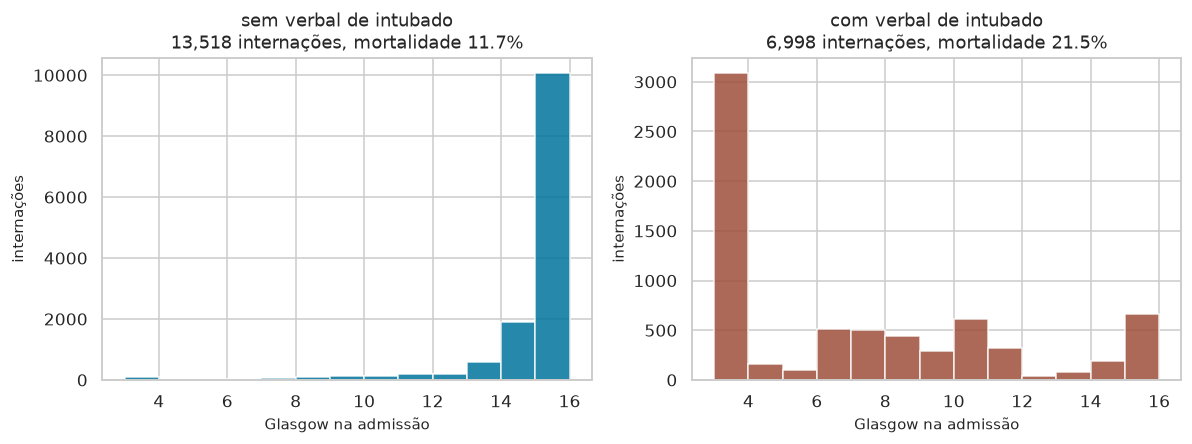

In [18]:
# Como o Glasgow se distribui, com e sem intubação registrada.
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.2))
for eixo, (intubado, titulo) in zip(
    eixos, [(False, "sem verbal de intubado"), (True, "com verbal de intubado")], strict=True
):
    dados = com_gcs[com_gcs.glasgow_intubado == intubado]
    eixo.hist(
        dados.gcs_admissao.dropna(),
        bins=range(3, 17),
        color="#00739c" if not intubado else "#9e4f3b",
        edgecolor="white",
        alpha=0.85,
    )
    eixo.set_title(f"{titulo}\n{len(dados):,} internações, mortalidade {dados[OUTCOME].mean():.1%}")
    eixo.set_xlabel("Glasgow na admissão")
    eixo.set_ylabel("internações")
plt.tight_layout()
plt.show()

> **Como ler estes gráficos.** À esquerda, quem nunca teve resposta verbal de intubado: a distribuição se concentra em 15, o Glasgow de quem está acordado e orientado. À direita, os intubados: um acúmulo em 3 que não é coma, é sedação e tubo.

### 4.4 A origem da medida de pressão

A Entrega 1 supôs que o cateter arterial marcaria gravidade, já que é colocado em quem o médico considera mais grave. A Entrega 2 encontrou o inverso, em 992 internações. Vale conferir em vinte vezes mais.

In [19]:
pressao = val[val.origem_pressao.notna()]
resumo_pressao = pressao.groupby("origem_pressao").agg(
    internacoes=(OUTCOME, "size"),
    mortalidade=(OUTCOME, "mean"),
    pressao_mediana=("Systolic BP", "median"),
)
print(resumo_pressao.to_string(formatters={"mortalidade": "{:.1%}".format}))
print("\nna Entrega 2: cateter 11,5% (200 internações) contra manguito 17,3% (792)")

                internacoes mortalidade  pressao_mediana
origem_pressao                                          
invasiva               4065       10.6%            115.0
nao invasiva          16416       16.2%            121.0

na Entrega 2: cateter 11,5% (200 internações) contra manguito 17,3% (792)


> **O que isso mostra.** O achado da Entrega 2 se confirma em vinte vezes mais internações, e continua contrariando o que a Entrega 1 supunha: quem teve cateter arterial morreu **menos** (10,6% contra 16,2%), apesar de ter pressão sistólica mediana mais baixa, 115 contra 121 mmHg.
>
> A explicação mais plausível segue a mesma: o cateter acompanha cirurgia programada e vigilância intensiva, não deterioração. É um marcador de processo assistencial, não de fisiologia.
>
> O que isso obriga, na prática, é registrar a origem da medida junto com a pressão. Um modelo que use pressão arterial sem saber de onde ela veio mistura o paciente com a decisão de monitorá-lo.

### 4.5 Confronto com a literatura

A Entrega 1 selecionou os candidatos a partir de trabalhos publicados. Aqui os efeitos medidos nesta coorte são postos ao lado do que esses trabalhos relataram. A comparação é de direção e ordem de grandeza: os estudos usam desfechos, janelas e ajustes diferentes, e razão de risco não é razão de chances.

In [20]:
# Efeito de cada medida por desvio-padrão, ajustado por idade e Glasgow, na validação.
# Razão de chances por DP é a forma comparável com o que a literatura costuma relatar.
linhas = []
for medida in ["RDW", "Anion Gap", "Urea Nitrogen", "Lactate", "Hemoglobin", "Sodium"]:
    colunas = REFERENCIA + [medida]
    d = val[colunas + [OUTCOME]].dropna().copy()
    dp = d[medida].std()
    d[medida] = d[medida] / dp
    m = LogisticRegression(max_iter=2000).fit(d[colunas], d[OUTCOME])
    coef = m.coef_[0][colunas.index(medida)]
    linhas.append(
        {
            "medida": medida,
            "desvio-padrão": round(dp, 2),
            "razão de chances por DP": round(np.exp(coef), 2),
            "n": len(d),
        }
    )
por_dp = pd.DataFrame(linhas)
por_dp

,medida,desvio-padrão,razão de chances por DP,n
0,RDW,2.35,1.55,20008
1,Anion Gap,4.28,1.76,20151
2,Urea Nitrogen,24.84,1.50,20166
3,Lactate,1.81,1.76,12828
4,Hemoglobin,2.17,0.94,20020
5,Sodium,4.92,0.87,20179


> **O que isso mostra, e como comparar com a literatura.** Os efeitos por desvio-padrão, ajustados por idade e Glasgow, colocam o ânion gap e o lactato na frente, com razão de chances de 1,76, seguidos do RDW com 1,55 e da ureia com 1,50. Sódio (0,87) e hemoglobina (0,94) apontam na direção esperada, valores mais baixos associados a mais óbito, com magnitude pequena.
>
> O confronto com os trabalhos que originaram cada candidato, na Entrega 1:
>
> **RDW.** Felker e colaboradores, avaliando 36 exames de rotina em 2.679 pacientes do programa CHARM, encontraram razão de risco ajustada de 1,17 por desvio-padrão para morbidade e mortalidade. Aqui a razão de chances é 1,55 por desvio-padrão. A direção é a mesma e a magnitude é maior, o que é coerente com as diferenças de desenho: desfecho hospitalar em vez de longo prazo, população de UTI em vez de ambulatorial, e ajuste por duas variáveis em vez do conjunto de covariáveis daquele estudo. O corte de 14,96%, vindo de um estudo no próprio MIMIC-IV, reproduz razão de chances de 2,02 nesta coorte.
>
> **Ureia.** O registro ADHERE, com 65.275 internações, colocou a ureia de admissão como primeiro nó da sua árvore de estratificação. O corte de 43 mg/dL leva a mortalidade de 11,6% para 22,6% aqui, razão de chances de 2,21. É a confirmação mais direta de literatura neste trabalho.
>
> **Razão ureia/creatinina.** Matsue e Murata relataram razões de risco de 1,86 e 1,81 para mortalidade por todas as causas, independentes de ureia e creatinina isoladas. Nesta coorte a razão não acrescenta discriminação (0,004), e a verificação da Entrega 2 explicou por quê: ela não se correlaciona com o sódio na direção que o mecanismo neuro-hormonal exigiria. Os desfechos não são os mesmos, mortalidade de longo prazo contra óbito hospitalar, o que basta para explicar parte da diferença, mas não sustenta a razão como candidata aqui.
>
> **Hiponatremia.** A meta-análise de Wang, Zhou e Yin associa sódio baixo a mortalidade em IC descompensada. O corte reproduz o efeito (razão de chances 1,53), o valor contínuo não acrescenta discriminação. Coerente com a literatura e sem utilidade preditiva incremental.
>
> **Lactato.** A literatura revisada na Entrega 1 já descrevia mecanismo plural: hipoperfusão, glicólise aeróbica sob estímulo adrenérgico e depuração hepática reduzida. Nada aqui separa esses mecanismos, e o ganho observado convive com o problema de seleção da seção 4.2.

### 4.6 Plausibilidade clínica e biológica

Replicação estatística não é explicação. Vale perguntar, para cada medida que sobreviveu, se existe mecanismo que a ligue ao desfecho, ou se ela é apenas um número que acompanha gravidade.

**Ânion gap e bicarbonato** descrevem acidose metabólica. Num coração que não entrega débito suficiente, o metabolismo anaeróbico e a retenção de ácidos sobem o ânion gap e consomem bicarbonato. É a repercussão sistêmica direta da falência de bomba, e explica por que são as duas medidas mais estáveis entre desenvolvimento e validação.

**Ureia e creatinina** descrevem a síndrome cardiorrenal. A ureia sobe não só por queda de filtração, mas por reabsorção tubular acoplada à avidez por sódio e água sob estímulo neuro-hormonal, e é por isso que ela discrimina mais que a creatinina (0,045 contra 0,027) apesar de as duas medirem o rim. O mecanismo é o mesmo que a Entrega 1 descreveu; o que não se sustentou foi a tentativa de isolá-lo pela razão entre as duas.

**RDW** é o caso menos específico e o mais replicado. Anisocitose reflete eritropoiese ineficaz por inflamação crônica, estresse oxidativo e carência nutricional, e prediz mortalidade em praticamente toda condição em que foi estudada. Isso é uma ressalva, não um defeito: ele parece marcar fragilidade biológica, não uma via da insuficiência cardíaca. Para a decisão em questão, marcar fragilidade basta.

**Lactato** tem mecanismo plural e não separável aqui, como a Entrega 1 já registrava.

**Pressão sistólica, frequência cardíaca e frequência respiratória** descrevem débito insuficiente e a resposta compensatória. A frequência respiratória, recuperada nesta etapa, é a mais barata de todas as medidas do trabalho e não exige exame nenhum.

**A razão neutrófilos/linfócitos** tem mecanismo plausível, inflamação e resposta ao estresse, e o problema dela aqui não é biológico: é que só existe em 38% das internações, e nas escolhidas por quem pediu o exame.

Nenhuma dessas leituras afirma causa. Todas descrevem por que a associação observada faz sentido fisiológico, que é o requisito para um candidato seguir sendo investigado.

## 5 Limitações

**A validação é interna, não externa.** As 20.619 internações vêm do mesmo hospital, do mesmo sistema de registro e do mesmo período das 1.000 de desenvolvimento. Isso mede otimismo de amostra, que era a pergunta desta etapa, e **não** mede transporte para outro centro, outra população ou outra rotina de exames. Um modelo pode atravessar uma divisão aleatória e falhar noutro hospital.

**As probabilidades precisam de recalibragem.** A inclinação de 0,747 mostra previsões esticadas para as pontas. O modelo ordena bem e anuncia mal.

**A ausência é informativa e não foi resolvida.** Pedir lactato tem razão de chances 2,18 e pedir albumina 1,75. Os ganhos de lactato e da razão neutrófilos/linfócitos valem em subgrupos escolhidos pelo julgamento clínico, e nenhum método aqui corrige isso.

**O Glasgow mistura consciência e intubação.** Um terço das internações tem resposta verbal de paciente intubado, e 44,1% delas pontuam 3.

**A pressão arterial vem com um confundidor de processo.** A origem invasiva acompanha mortalidade menor, o inverso do esperado, e precisa acompanhar a variável.

**Faltam dados que explicariam associações.** Não há BNP, prescrições, balanço hídrico, função ventricular, eletrocardiograma nem radiografia. As duas verificações prometidas na Entrega 1, sobre diurético e massa muscular, seguem impossíveis, e elas enfraquecem justamente a leitura da razão ureia/creatinina e da creatinina.

**O desfecho é estreito.** Óbito hospitalar não cobre morte após a alta nem desfechos intermediários, e é sensível a prática de cuidados paliativos e a decisões de limitação terapêutica, que o corte não registra.

**O limiar de 0,010 de ganho é uma escolha da equipe.** Ele foi fixado antes dos resultados e manteve-se nas duas etapas, mas continua arbitrário: a frequência respiratória passa com 0,031 e o sódio falha com 0,007 por causa dele.

**Nada aqui é causal.** Os modelos são prognósticos. Nenhum resultado diz que tratar o ânion gap muda desfecho.

## 6 Potencial biomarcador prognóstico

O quadro abaixo fecha o trabalho: cada medida candidata, o que a Entrega 2 concluiu, o que a validação mostrou, e a recomendação. A regra de classificação é declarada no código, não escolhida caso a caso.

In [21]:
COBERTURA_MINIMA = 0.95

preenchimento = {m: val[m].notna().mean() for m in CANDIDATOS}
por_dp_mapa = dict(zip(por_dp.medida, por_dp["razão de chances por DP"], strict=True))


def classificar(linha):
    """Recomendação a partir do que a validação mostrou. Regra única para todos."""
    if not linha["sustentado na validação"]:
        return "abandonar"
    if preenchimento[linha.medida] < COBERTURA_MINIMA:
        return "manter com ressalva de seleção"
    if not linha.sustentado_entrega2:
        return "recuperado na validação"
    return "levar adiante"


veredicto = replicacao[
    [
        "medida",
        "ganho_entrega2",
        "ganho na validação",
        "sustentado_entrega2",
        "sustentado na validação",
    ]
].copy()
veredicto["preenchimento"] = veredicto.medida.map(preenchimento).map("{:.1%}".format)
veredicto["RC por DP"] = veredicto.medida.map(por_dp_mapa)
veredicto["recomendação"] = veredicto.apply(classificar, axis=1)
veredicto = veredicto.sort_values(["recomendação", "ganho na validação"], ascending=[True, False])

print(veredicto.recomendação.value_counts().to_string())
print()
print("modelo recomendado: idade + Glasgow + RDW + ânion gap")
print(
    f"  AUC na validação: {final['auc']:.3f} [{final['ic'][0]:.3f}–{final['ic'][1]:.3f}] "
    f"em {final['n_validacao']:,} internações"
)
print(f"  ganho sobre idade + Glasgow: {final['auc'] - ref['auc']:+.3f}")
print(
    f"  mortalidade nos 5% de maior risco: {y[risco >= np.sort(risco)[::-1][int(0.05*len(risco))-1]].mean():.1%}"
)
veredicto

recomendação
levar adiante                     7
abandonar                         3
manter com ressalva de seleção    2
recuperado na validação           1

modelo recomendado: idade + Glasgow + RDW + ânion gap
  AUC na validação: 0.713 [0.703–0.723] em 19,960 internações
  ganho sobre idade + Glasgow: +0.089
  mortalidade nos 5% de maior risco: 50.5%


,medida,ganho_entrega2,ganho na validação,sustentado_entrega2,sustentado na validação,preenchimento,RC por DP,recomendação
9,Sodium,0.000,0.007,False,False,98.2%,0.87,abandonar
1,razao_ureia_creatinina,0.002,0.004,False,False,98.2%,NaN,abandonar
8,Hemoglobin,-0.005,-0.001,False,False,97.5%,0.94,abandonar
4,Anion Gap,0.072,0.068,True,True,98.1%,1.76,levar adiante
3,RDW,0.080,0.057,True,True,97.4%,1.55,levar adiante
0,Urea Nitrogen,0.037,0.045,True,True,98.2%,1.50,levar adiante
5,Bicarbonate,0.037,0.030,True,True,98.2%,NaN,levar adiante
2,Creatinine,0.016,0.027,True,True,98.2%,NaN,levar adiante
10,Systolic BP,0.027,0.022,True,True,99.3%,NaN,levar adiante
11,Heart Rate,0.013,0.021,True,True,99.9%,NaN,levar adiante


### 6.1 As quatro perguntas da Entrega 3

**O resultado é coerente com o que se conhece sobre insuficiência cardíaca?** Sim, e em dois níveis. Os efeitos vão todos na direção que a fisiologia prevê, e os dois cortes publicados que a Entrega 1 trouxe se reproduzem: ureia de 43 mg/dL leva a mortalidade de 11,6% para 22,6%, e RDW de 14,96% de 10,0% para 18,4%. O único conflito com a literatura é a razão ureia/creatinina, e ele é explicável pela diferença de desfecho e pela verificação de mecanismo que falhou na Entrega 2.

**Existe plausibilidade clínica e biológica?** Sim para todas as medidas sustentadas, com mecanismos descritos na seção 4.6. Com uma ressalva de natureza diferente para o RDW, que prediz mortalidade em quase toda doença estudada e por isso parece marcar fragilidade, e não uma via da insuficiência cardíaca.

**O biomarcador acrescentaria informação potencialmente útil à decisão proposta?** Sim, e isso é o que a validação sustenta com mais firmeza. RDW e ânion gap acrescentam 0,089 de AUC sobre idade e Glasgow em 19.960 internações nunca vistas, quase o mesmo acréscimo medido no desenvolvimento. Na prática da decisão que o projeto quer apoiar, sinalizar os 5% de maior risco isola um grupo com 50,5% de mortalidade contra 12,8% no restante. São exames de rotina, disponíveis em mais de 97% das internações, sem custo adicional de coleta.

**A evidência obtida neste dataset é suficiente para considerá-lo um biomarcador validado?** **Não.** A palavra validado exige mais do que este trabalho pode dar, por três razões concretas. A validação é interna: mesma instituição, mesmo sistema de registro, mesmo período. As probabilidades não estão calibradas para uso individual. E a ausência de exame é informativa, o que restringe parte dos achados a subgrupos escolhidos pelo julgamento médico.

No vocabulário do FDA-NIH adotado na Entrega 1, o que existe aqui é **validação analítica em uma coorte, com replicação interna**, e não validação clínica. São biomarcadores prognósticos candidatos com evidência computacional replicada, prontos para a etapa seguinte, que este trabalho não executa.

### 6.2 O que a validação externa e clínica exigiria

**Validação externa, em ordem de esforço.** Repetir a análise no MIMIC-III, que é outro período do mesmo hospital, mede transporte no tempo. Repetir no eICU-CRD, que reúne mais de duzentos hospitais dos Estados Unidos, mede transporte entre instituições e é o teste que falta. Um corte brasileiro mediria transporte entre sistemas de saúde, e seria o mais informativo para o contexto deste projeto.

**Recalibragem antes de qualquer uso.** A inclinação de 0,747 precisa ser corrigida na população de destino, e a correção precisa ser reavaliada lá, não aqui.

**Tratar a ausência informativa de frente.** Enquanto pedir um exame prevê melhor que o resultado dele, qualquer modelo que use lactato ou diferencial de leucócitos está aprendendo parte do julgamento médico. Isso exige ou restringir o modelo a exames de rotina universal, que é o caminho que este trabalho escolheu, ou modelar explicitamente o processo de solicitação.

**Avaliação de utilidade, não só de desempenho.** AUC e calibração não dizem se a sinalização muda conduta. Isso exige análise de decisão com os custos e benefícios da unidade, e depois um estudo prospectivo que compare desfechos com e sem a informação disponível.

**Relato conforme diretriz.** O TRIPOD+AI define o que um modelo prognóstico precisa publicar para ser avaliável por terceiros. Seguir a lista é o passo mais baratо e o mais frequentemente omitido.

**O que este trabalho entrega, ao fim.** Treze medidas candidatas foram propostas a partir da literatura, dez sobreviveram a uma validação em vinte mil internações nunca vistas, duas delas se destacam por acrescentarem informação real a custo zero, e nenhuma está validada. A diferença entre essas duas últimas frases é o resultado do CardioFusion.